# EDA — Student Performance Dataset
## Analyse Exploratoire des Données
**Objectif** : Comprendre la structure des données, identifier les features pertinentes et formuler des hypothèses pour la prédiction de la réussite scolaire.

In [67]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt

In [68]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

df_mat = pd.read_csv("student-mat.csv", sep=";")
df_por = pd.read_csv("student-por.csv", sep=";")
df_mat["course"] = "math"
df_por["course"] = "portuguese"
df = pd.concat([df_mat, df_por], ignore_index=True)

df["pass"] = (df["G3"] >= 10).astype(int)

print(f"Dataset : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"Réussite : {df['pass'].sum()} ({df['pass'].mean()*100:.1f}%)")
print(f"Échec    : {(df['pass']==0).sum()} ({(1-df['pass'].mean())*100:.1f}%)")

Dataset : 1044 lignes × 35 colonnes
Réussite : 814 (78.0%)
Échec    : 230 (22.0%)


## 1. Aperçu général du dataset


In [69]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,goout,Dalc,Walc,health,absences,G1,G2,G3,course,pass
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,1,1,3,6,5,6,6,math,0
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,1,1,3,4,5,5,6,math,0
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,2,2,3,3,10,7,8,10,math,1
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,1,1,5,2,15,14,15,math,1
4,GP,F,16,U,GT3,T,3,3,other,other,...,2,1,2,5,4,6,10,10,math,1


In [70]:
df.describe().round(2)

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,pass
count,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00
mean,16.73,2.60,2.39,1.52,1.97,0.26,3.94,3.20,3.16,1.49,2.28,3.54,4.43,11.21,11.25,11.34,0.78
std,1.24,1.12,1.10,0.73,0.83,0.66,0.93,1.03,1.15,0.91,1.29,1.42,6.21,2.98,3.29,3.86,0.41
min,15.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00
25%,16.00,2.00,1.00,1.00,1.00,0.00,4.00,3.00,2.00,1.00,1.00,3.00,0.00,9.00,9.00,10.00,1.00
50%,17.00,3.00,2.00,1.00,2.00,0.00,4.00,3.00,3.00,1.00,2.00,4.00,2.00,11.00,11.00,11.00,1.00
75%,18.00,4.00,3.00,2.00,2.00,0.00,5.00,4.00,4.00,2.00,3.00,5.00,6.00,13.00,13.00,14.00,1.00
max,22.00,4.00,4.00,4.00,4.00,3.00,5.00,5.00,5.00,5.00,5.00,5.00,75.00,19.00,19.00,20.00,1.00


In [71]:
print("Valeurs manquantes par colonne :")
print(df.isnull().sum().sum(), "valeurs manquantes au total")
print("\nTypes de colonnes :")
print(df.dtypes.value_counts())

Valeurs manquantes par colonne :
0 valeurs manquantes au total

Types de colonnes :
str      18
int64    17
Name: count, dtype: int64


## 2. Distribution de la variable cible

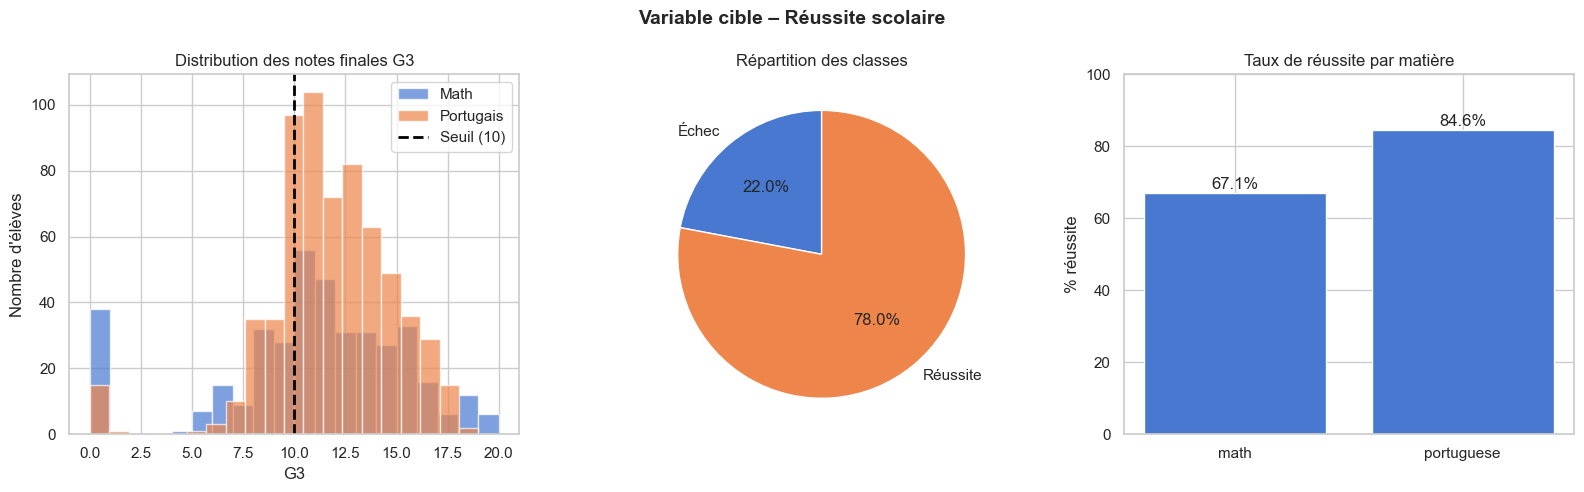

Taux de réussite : 0.78


In [73]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Variable cible – Réussite scolaire", fontsize=14, fontweight="bold")

# 1. Distribution des notes finales G3
axes[0].hist(df_mat["G3"], bins=20, alpha=0.7, label="Math")
axes[0].hist(df_por["G3"], bins=20, alpha=0.7, label="Portugais")
axes[0].axvline(10, color="black", linestyle="--", lw=2, label="Seuil (10)")
axes[0].set_title("Distribution des notes finales G3")
axes[0].set_xlabel("G3")
axes[0].set_ylabel("Nombre d'élèves")
axes[0].legend()

# 2. Répartition réussite / échec
counts = df["pass"].value_counts().sort_index()

axes[1].pie(
    counts,
    labels=["Échec", "Réussite"],
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Répartition des classes")

# 3. Taux de réussite par matière
pass_by_course = df.groupby("course")["pass"].mean() * 100

axes[2].bar(pass_by_course.index, pass_by_course.values)
axes[2].set_title("Taux de réussite par matière")
axes[2].set_ylabel("% réussite")
axes[2].set_ylim(0, 100)

for i, v in enumerate(pass_by_course.values):
    axes[2].text(i, v + 1, f"{v:.1f}%", ha="center")

plt.tight_layout()
plt.show()

print("Taux de réussite :", round(df["pass"].mean(), 3))

## 3. Analyse des features numériques

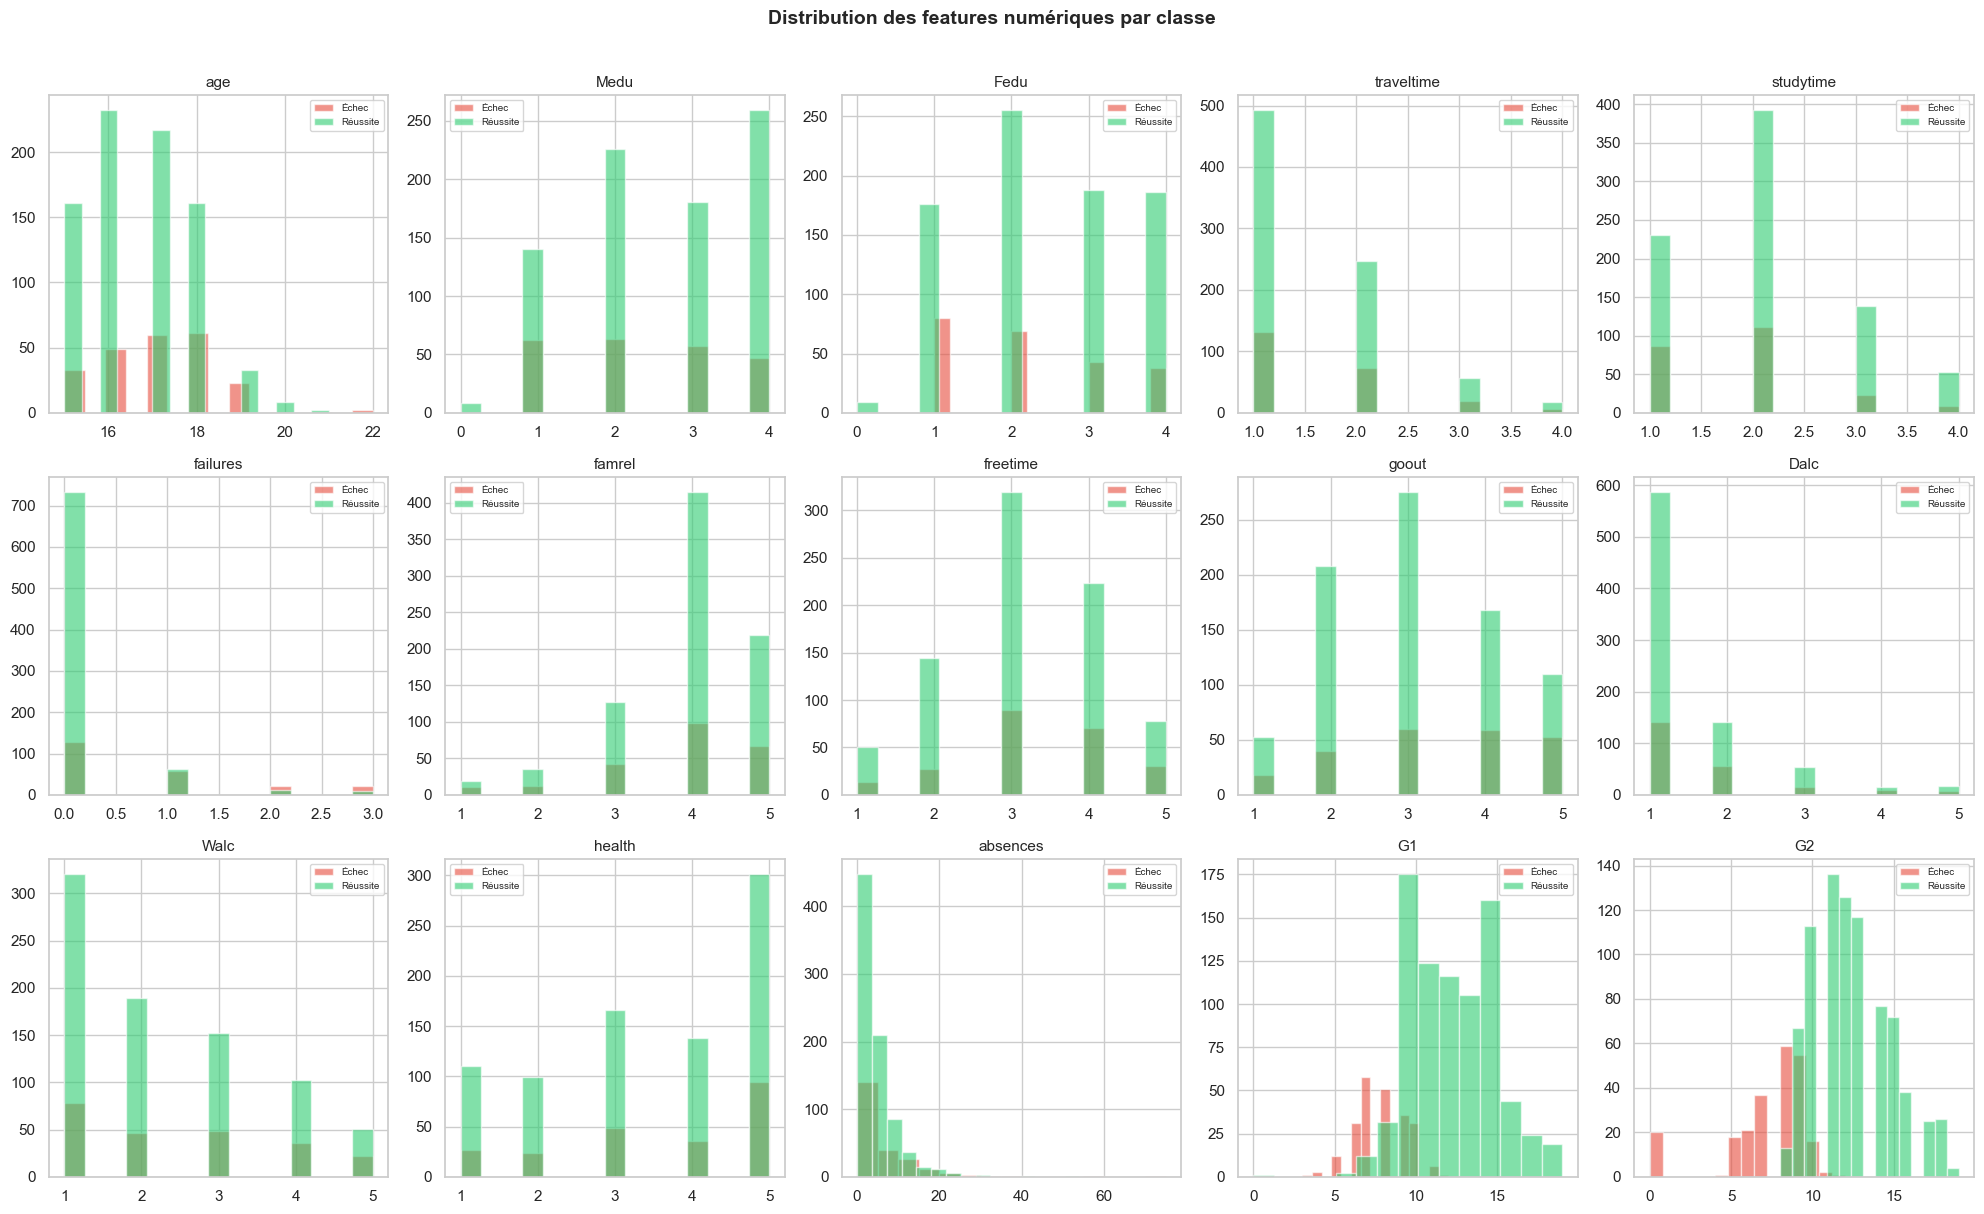

In [ ]:
numeric_cols = ["age", "Medu", "Fedu", "traveltime", "studytime",
                "failures", "famrel", "freetime", "goout",
                "Dalc", "Walc", "health", "absences", "G1", "G2"]

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    for cls, label, color in zip([0, 1], ["Échec", "Réussite"], ["#E74C3C", "#2ECC71"]):
        axes[i].hist(df[df["pass"]==cls][col], bins=15, alpha=0.6, color=color, label=label)
    axes[i].set_title(col, fontsize=11)
    axes[i].legend(fontsize=7)

plt.suptitle("Distribution des features numériques par classe", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## 4. Corrélations avec la réussite

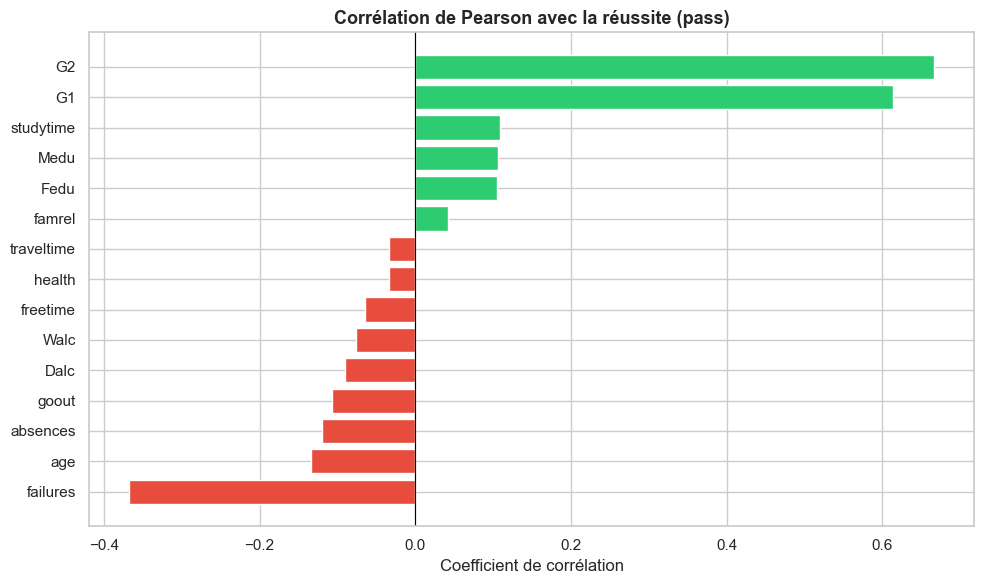

Top 5 features positivement corrélées à la réussite :
Fedu         0.105579
Medu         0.106460
studytime    0.108553
G1           0.613927
G2           0.666289

Top 5 features négativement corrélées à la réussite :
failures   -0.367183
age        -0.134276
absences   -0.119142
goout      -0.106506
Dalc       -0.089581


In [75]:
# Corrélation de chaque feature numérique avec la target
corr_with_target = df[numeric_cols + ["pass"]].corr()["pass"].drop("pass").sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#E74C3C" if x < 0 else "#2ECC71" for x in corr_with_target.values]
bars = ax.barh(corr_with_target.index, corr_with_target.values, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Corrélation de Pearson avec la réussite (pass)", fontsize=13, fontweight="bold")
ax.set_xlabel("Coefficient de corrélation")
plt.tight_layout()
plt.show()

print("Top 5 features positivement corrélées à la réussite :")
print(corr_with_target.tail(5).to_string())
print("\nTop 5 features négativement corrélées à la réussite :")
print(corr_with_target.head(5).to_string())


## 5. Analyse des features catégorielles

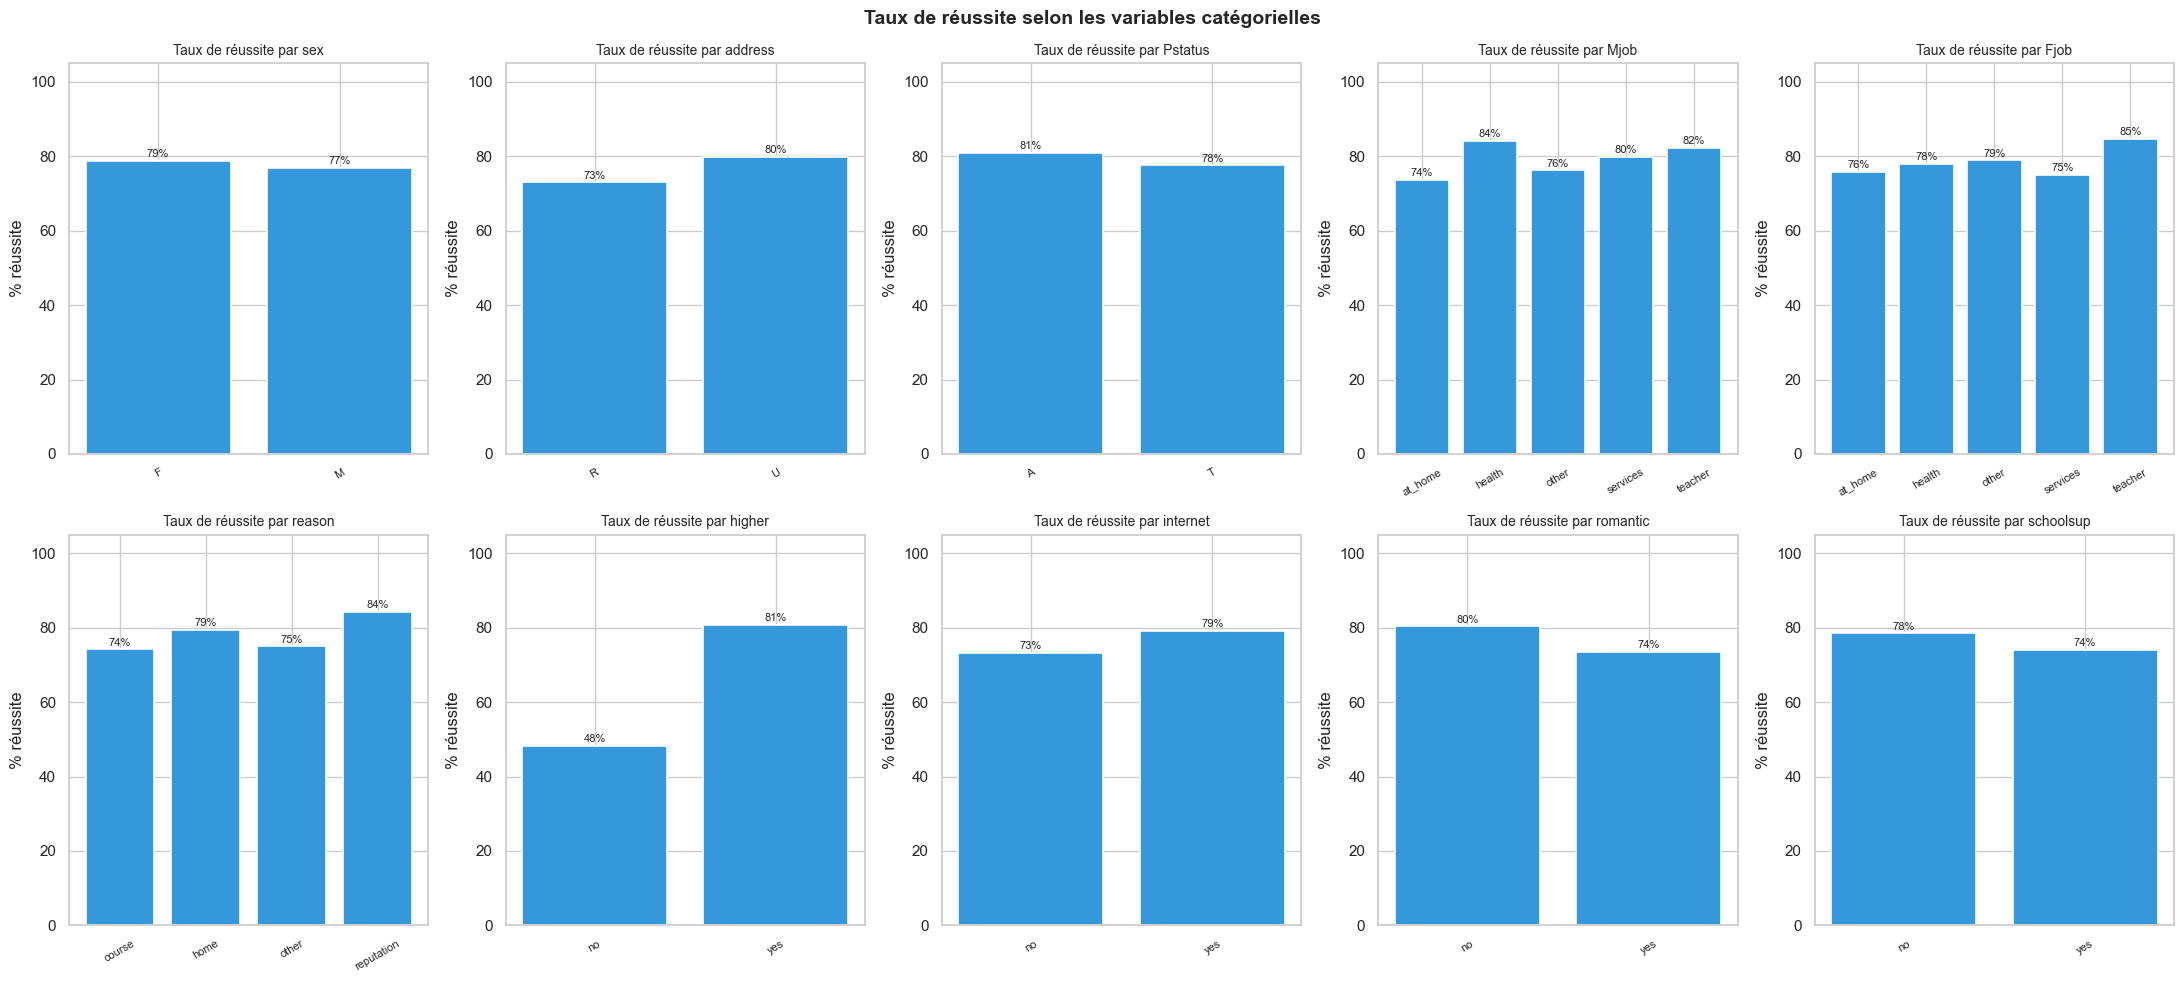

In [76]:
cat_cols = ["sex", "address", "Pstatus", "Mjob", "Fjob",
            "reason", "higher", "internet", "romantic", "schoolsup"]

fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    pass_rate = df.groupby(col)["pass"].mean() * 100
    bars = axes[i].bar(pass_rate.index.astype(str), pass_rate.values,
                       color="#3498DB", edgecolor="white", linewidth=1.2)
    axes[i].set_title(f"Taux de réussite par {col}", fontsize=10)
    axes[i].set_ylabel("% réussite")
    axes[i].set_ylim(0, 105)
    axes[i].tick_params(axis='x', rotation=30, labelsize=8)
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f"{bar.get_height():.0f}%", ha="center", fontsize=8)

plt.suptitle("Taux de réussite selon les variables catégorielles", fontsize=14, fontweight="bold")
plt.tight_layout()

plt.show()


## 6. Matrice de corrélation globale

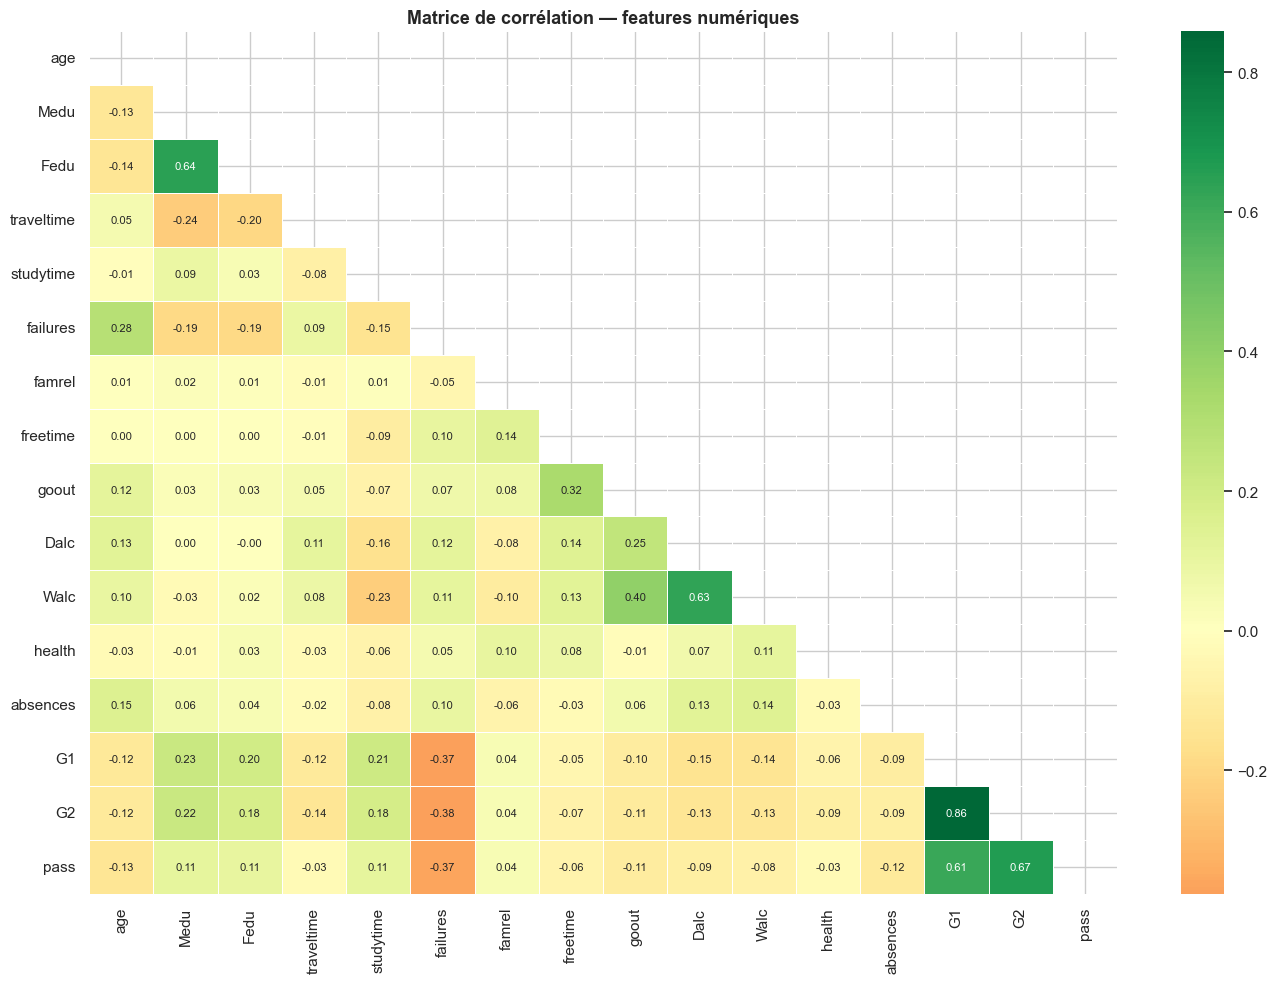

In [77]:
fig, ax = plt.subplots(figsize=(14, 10))
corr_matrix = df[numeric_cols + ["pass"]].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, linewidths=0.5,
            annot_kws={"size": 8}, ax=ax)
ax.set_title("Matrice de corrélation — features numériques", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 7. Relation entre les notes G1, G2 et G3

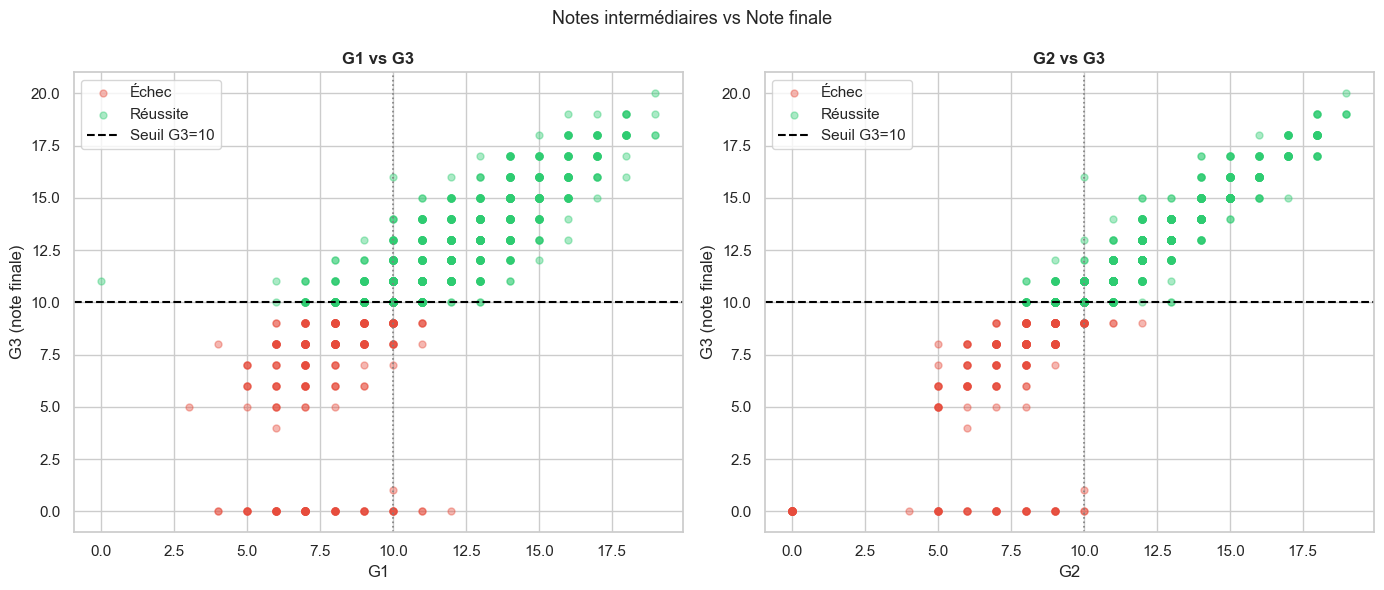

Corrélation G1-G3 : 0.809
Corrélation G2-G3 : 0.911


In [78]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (x_col, title) in zip(axes, [("G1", "G1 vs G3"), ("G2", "G2 vs G3")]):
    for cls, label, color in zip([0, 1], ["Échec", "Réussite"], ["#E74C3C", "#2ECC71"]):
        subset = df[df["pass"] == cls]
        ax.scatter(subset[x_col], subset["G3"], alpha=0.4, color=color, label=label, s=25)
    ax.axhline(10, color="black", linestyle="--", lw=1.5, label="Seuil G3=10")
    ax.axvline(10, color="gray", linestyle=":", lw=1.2)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel(x_col)
    ax.set_ylabel("G3 (note finale)")
    ax.legend()

plt.suptitle("Notes intermédiaires vs Note finale", fontsize=13)
plt.tight_layout()

plt.show()

print(f"Corrélation G1-G3 : {df['G1'].corr(df['G3']):.3f}")
print(f"Corrélation G2-G3 : {df['G2'].corr(df['G3']):.3f}")
